# Colour profiles and colour management

Two slides of the same tissue, scanned on two different scanners, will not
produce the same RGB numbers. Each scanner has its own sensor response, its own
illumination and its own idea of what "255, 255, 255" means. A pixel value on
its own is therefore not a colour — it is a device reading, and it is only a
colour once you know which device produced it.

That knowledge is what an **ICC profile** is: a description, embedded in the
file by the scanner, of how that device's numbers map onto real colour. SlideIO
exposes it in two halves:

- **reading** the profile — what does this scene say about its own colour?
- **using** it — convert the pixels through the profile into a space that means
  the same thing whatever produced the file.

This is a different operation from the one in
[color-transformations.ipynb](./color-transformations.ipynb). `ColorTransformation`
rearranges numbers between colour spaces: RGB to HSV, RGB to grayscale. The
arithmetic is fixed, and it does not consult the file. `ColorManagement` asks
what the numbers *mean* first. Converting the same slide to Lab through the two
routes gives different answers, and only the colour-managed one is comparable
across scanners.

This notebook covers:

1. what a scene reports about its profile
2. provenance — `ColorProfileSource`, and why a pipeline should record it
3. converting: the four `ColorTarget`s
4. rendering intent and black point compensation
5. slides that carry no profile at all
6. supplying a profile yourself
7. composing colour management with other transformations

The colour API requires **slideio 2.10.0 or newer**.

In [1]:
import slideio
from utils import get_driver_test_images, display_driver_test_image_info, \
                    show_image, show_images
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
slideio.get_version()

'2.10.0'

# Test images

Three of the images shipped with this repository are used below, each for a
reason:

| image | driver | why |
|---|---|---|
| `Airbus_Pleiades_50cm_8bit_RGB_Yogyakarta.jpg` | GDAL | carries a real embedded ICC profile |
| `CMU-1-Small-Region.svs` | SVS | a pathology slide that carries **no** profile — the common case |
| `FluorCell_4/3_0` | DCM | embeds a large v4 profile, used later as a donor |

The pathology slide being the unprofiled one is not an accident of this
repository. Most whole-slide formats in routine use embed nothing, which is
precisely why the missing-profile behaviour in section 5 matters more than it
might appear.

In [3]:
profiled = './images/Airbus_Pleiades_50cm_8bit_RGB_Yogyakarta.jpg'
unprofiled = './images/CMU-1-Small-Region.svs'
donor_path = './images/FluorCell_4/3_0'

display_driver_test_image_info(
    get_driver_test_images('GDAL') + get_driver_test_images('SVS'), 'GDAL')

Image Path,Driver
./images/Airbus_Pleiades_50cm_8bit_RGB_Yogyakarta.jpg,GDAL
./images/CMU-1-Small-Region.svs,SVS


# 1. What a scene reports about its profile

A scene answers two questions about its colour.

`get_color_profile()` returns the **raw ICC bytes** exactly as they sit in the
file, or `None` if there are none. `None` rather than `b''`: absence reads as
absence, so `if scene.get_color_profile():` and `is not None` agree with each
other.

`get_color_profile_info()` returns a `ColorProfileInfo` — the profile's header,
already parsed, so that the common questions ("is there one?", "what colour
space?", "how big?") do not require an ICC parser of your own.

In [4]:
slide = slideio.open_slide(profiled, 'GDAL')
scene = slide.get_scene(0)

icc = scene.get_color_profile()

print('scene size        :', scene.size)
print('channels          :', scene.num_channels)
print('profile bytes     :', len(icc))
print('first 4 bytes     :', icc[:4], '(the ICC profile size field)')
print('signature at 36:40:', icc[36:40], '(always b"acsp" in a valid profile)')

scene size        : (5494, 5839)
channels          : 3
profile bytes     : 3144
first 4 bytes     : b'\x00\x00\x0cH' (the ICC profile size field)
signature at 36:40: b'acsp' (always b"acsp" in a valid profile)


The parsed header carries rather more than "present or not".

In [5]:
info = scene.get_color_profile_info()

pd.DataFrame(
    [
        ('present', info.present),
        ('source', info.source),
        ('description', info.description),
        ('manufacturer', info.manufacturer),
        ('model', info.model),
        ('version', info.version),
        ('data_space', info.data_space),
        ('connection_space', info.connection_space),
        ('intent', info.intent),
        ('white_point', np.round(info.white_point, 4).tolist()),
        ('size', info.size),
    ],
    columns=['field', 'value'],
).set_index('field')

,value
field,
present,True
source,ColorProfileSource.EMBEDDED
description,sRGB IEC61966-2.1
manufacturer,IEC http://www.iec.ch
model,IEC 61966-2.1 Default RGB colour space - sRGB
version,2.1
data_space,IccColorSpace.RGB
connection_space,IccColorSpace.XYZ
intent,RenderingIntent.RELATIVE_COLORIMETRIC


Three of those fields do real work later:

- **`data_space`** is the space the profile's *input* is in — `RGB` here. A
  `Gray` or `CMYK` profile is a perfectly valid ICC profile and a perfectly
  useless one to hand to a three-channel conversion.
- **`connection_space`** is the profile connection space, `XYZ` or `Lab`. It is
  the hub every conversion passes through.
- **`intent`** is the profile's *own declared preference*, not what SlideIO will
  use. The intent actually applied is the one you set on `ColorManagement`
  (section 4); this field only tells you what the profile's author had in mind.

`ColorProfileInfo` also prints itself usefully, which is generally enough when
logging.

In [6]:
info

ColorProfileInfo(present=true, source=Embedded, description='sRGB IEC61966-2.1', space=RGB, pcs=XYZ, intent=RelativeColorimetric, size=3144)

### The bytes are a real profile, not just non-empty

`get_color_profile()` hands back the profile untouched, which means any ICC
consumer can take it. Round-tripping it through Pillow's `ImageCms` is a cheap
way to prove that — and a realistic one, since attaching the slide's profile to
an exported PNG or JPEG is exactly what you would do with these bytes.

In [7]:
import io
from PIL import ImageCms

pil_profile = ImageCms.ImageCmsProfile(io.BytesIO(icc))

print('description  :', ImageCms.getProfileDescription(pil_profile).strip())
print('copyright    :', ImageCms.getProfileCopyright(pil_profile).strip()[:44])
print('colour space :', pil_profile.profile.xcolor_space.strip(),
      '-> connection space', pil_profile.profile.connection_space.strip())
print('device class :', pil_profile.profile.device_class.strip())

description  : sRGB IEC61966-2.1
copyright    : Copyright (c) 1998 Hewlett-Packard Company
colour space : RGB -> connection space XYZ
device class : mntr


### A scene with no profile

Most pathology slides carry nothing. The API is designed so that this case is
quiet rather than exceptional: `None` bytes, and a `ColorProfileInfo` whose
`present` is `False`.

In [8]:
plain_slide = slideio.open_slide(unprofiled, 'SVS')
plain = plain_slide.get_scene(0)

print('profile bytes :', plain.get_color_profile())
print('info          :', plain.get_color_profile_info())
print('present       :', plain.get_color_profile_info().present)
print('source        :', plain.get_color_profile_info().source)

profile bytes : None
info          : ColorProfileInfo(present=false, source=None)
present       : False
source        : ColorProfileSource.NONE


# 2. Provenance: `ColorProfileSource`

`info.source` is the field to record if you record only one. It does not say
what the colour is — it says **where the claim came from**, and those are very
different levels of confidence:

| source | meaning |
|---|---|
| `NONE` | no profile; the pixels are uninterpreted device values |
| `EMBEDDED` | the profile came out of the file — the scanner's own claim |
| `ASSUMED` | nothing was in the file, so sRGB was assumed — a guess |
| `SUPPLIED` | you provided the profile yourself (section 6) |

A colour-managed scene always reports `present=True`, so `present` alone cannot
tell a measurement from a guess. `source` can. For anything whose output is
going to be compared across sites or defended later, `ASSUMED` is the value that
should make a pipeline log loudly, or stop.

The cell below converts both slides and inspects the provenance of the results.

In [9]:
def managed(scene, **settings):
    """Apply a ColorManagement transformation with the given settings."""
    cm = slideio.ColorManagement()
    for name, value in settings.items():
        setattr(cm, name, value)
    return scene.apply_transformation([cm])


rows = []
for label, source_scene in [('profiled JPEG', scene), ('unprofiled SVS', plain)]:
    before = source_scene.get_color_profile_info()
    after = managed(source_scene, target=slideio.ColorTarget.SRGB).get_color_profile_info()
    rows.append({
        'scene': label,
        'source before': before.source,
        'source after': after.source,
        'description after': after.description,
    })

pd.DataFrame(rows).set_index('scene')

,source before,source after,description after
scene,,,
profiled JPEG,ColorProfileSource.EMBEDDED,ColorProfileSource.EMBEDDED,sRGB IEC61966-2.1
unprofiled SVS,ColorProfileSource.NONE,ColorProfileSource.ASSUMED,sRGB built-in


The profiled scene keeps `EMBEDDED`: a real conversion was performed, from the
profile the file carried. The unprofiled scene comes back `ASSUMED` — it was
converted, the pixels did change, and the only thing justifying the change is a
default. Both are now "colour managed"; only one of them is evidence.

`slideio.transform_scene(scene, [cm])` is equivalent to
`scene.apply_transformation([cm])` and is used interchangeably in the SlideIO
documentation. Either returns a new `Scene` — nothing is read, and no pixel is
converted, until you call `read_block` on it.

# 3. Converting: the four `ColorTarget`s

`ColorManagement.target` chooses what the conversion produces. The four targets
differ in more than colour space: two of them change the data type of what
`read_block` returns.

| target | output | range | what it is for |
|---|---|---|---|
| `SRGB` | uint8 | 0–255 | display, export, feeding models trained on sRGB |
| `LINEAR_RGB` | float32 | 0–1 | arithmetic on light: blending, resampling, unmixing |
| `LAB` | float32 | L 0–100, a/b ±128 | perceptual distance, stain normalisation |
| `XYZ` | float32 | 0–1 | an intermediate, or input to a further colorimetric step |

`LINEAR_RGB` deserves a note. sRGB values are gamma encoded, so averaging two of
them does not average the light they represent — downscaling an image in sRGB
darkens it slightly. Any pipeline doing arithmetic over pixels rather than just
classifying them wants linear data.

In [10]:
targets = [
    ('SRGB', slideio.ColorTarget.SRGB),
    ('LINEAR_RGB', slideio.ColorTarget.LINEAR_RGB),
    ('LAB', slideio.ColorTarget.LAB),
    ('XYZ', slideio.ColorTarget.XYZ),
]

converted = {}
rows = []
for name, target in targets:
    block = managed(scene, target=target).read_block(size=(400, 0))
    converted[name] = block
    rows.append({
        'target': name,
        'dtype': block.dtype.name,
        'shape': block.shape,
        # + 0.0 turns a rounded -0.0 back into 0.0, which is what it means.
        'min': round(float(block.min()), 3) + 0.0 or 0.0,
        'max': round(float(block.max()), 3),
    })

pd.DataFrame(rows).set_index('target')

,dtype,shape,min,max
target,,,,
SRGB,uint8,"(425, 400, 3)",0.000,255.000
LINEAR_RGB,float32,"(425, 400, 3)",0.000,1.000
LAB,float32,"(425, 400, 3)",-59.899,99.999
XYZ,float32,"(425, 400, 3)",0.000,1.000


Only `SRGB` gives back 8-bit data. The other three are float32, because they are
physical or perceptual quantities and clipping them into a byte would throw away
the precision that made them worth computing.

The images below are the same region under each target, displayed raw. `SRGB` is
the only one meant to be looked at directly — the other three are shown to make
the point that they are *data*, not pictures: linear RGB looks washed out
because it has not been gamma encoded for a display, and Lab's channels are not
red, green and blue at all.

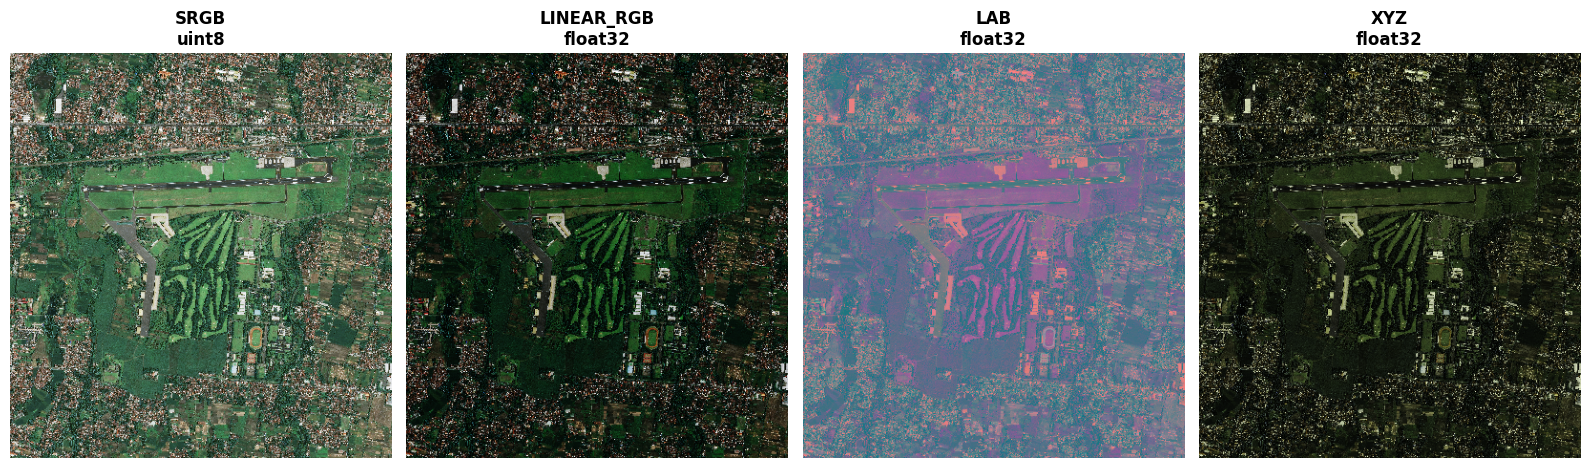

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, (name, _) in zip(axes, targets):
    block = converted[name]
    display_block = block if block.dtype == np.uint8 else np.clip(block, 0, 1)
    if name == 'LAB':
        display_block = np.clip(block / np.array([100.0, 255.0, 255.0]) +
                                np.array([0.0, 0.5, 0.5]), 0, 1)
    ax.imshow(display_block)
    ax.set_title(f'{name}\n{block.dtype.name}', fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()

Lab's channels separate lightness from colour, which is the property most of its
uses rest on. `L` alone is a better grayscale than any weighted sum of RGB,
because it is perceptual lightness rather than a guess at one.

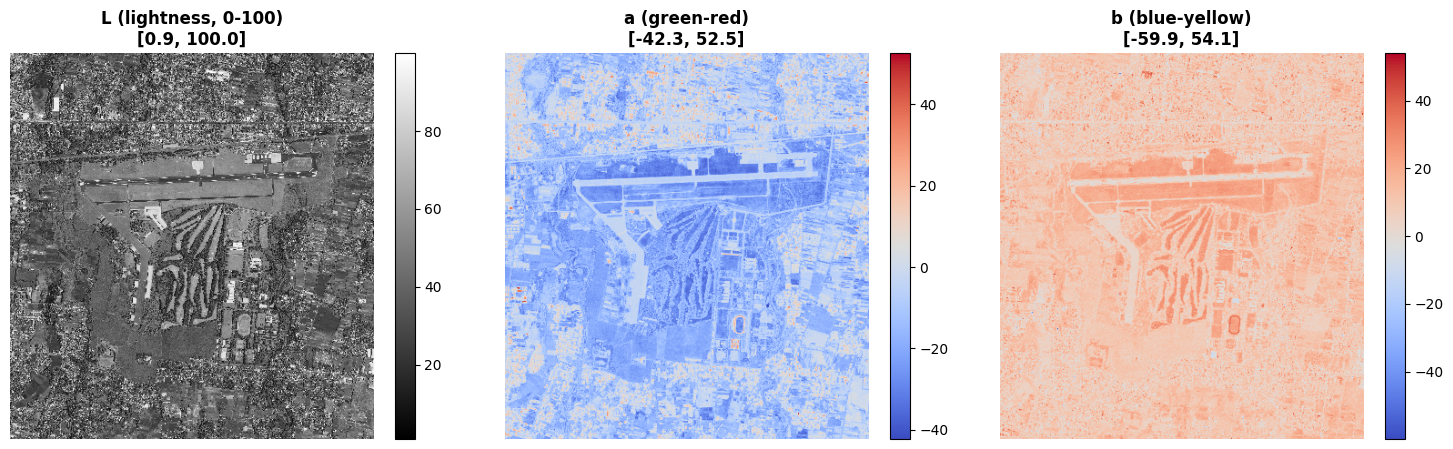

In [12]:
lab = converted['LAB']
names = ['L (lightness, 0-100)', 'a (green-red)', 'b (blue-yellow)']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for index, (ax, name) in enumerate(zip(axes, names)):
    channel = lab[:, :, index]
    image = ax.imshow(channel, cmap='gray' if index == 0 else 'coolwarm')
    ax.set_title(f'{name}\n[{channel.min():.1f}, {channel.max():.1f}]',
                 fontweight='bold')
    ax.axis('off')
    fig.colorbar(image, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

### Colour managed Lab is not the same as `ColorTransformation` Lab

`ColorTransformation` also offers a Lab conversion, and it is a different
number. It applies the textbook sRGB-to-Lab formula to whatever values it is
given, without asking what device produced them — and it returns uint8, in
OpenCV's scaled encoding, so the two are not even on the same axis until the
encoding is undone.

In [13]:
naive_params = slideio.ColorTransformation()
naive_params.color_space = slideio.ColorSpace.Lab
naive = scene.apply_transformation([naive_params]).read_block(size=(400, 0))

print('ColorTransformation Lab :', naive.dtype, naive.shape,
      f'range [{naive.min():.1f}, {naive.max():.1f}]')
print('ColorManagement Lab     :', lab.dtype, lab.shape,
      f'range [{lab.min():.1f}, {lab.max():.1f}]')

ColorTransformation Lab : uint8 (425, 400, 3) range [2.0, 255.0]
ColorManagement Lab     : float32 (425, 400, 3) range [-59.9, 100.0]


Undo the 8-bit encoding — `L * 100/255`, `a - 128`, `b - 128` — and the two are
comparable. This image is the favourable case: its profile really is sRGB, which
is exactly the assumption `ColorTransformation` hard-codes, so the two should
agree and very nearly do.

In [14]:
decoded = np.dstack([naive[:, :, 0] * (100.0 / 255.0),
                     naive[:, :, 1].astype(np.float32) - 128.0,
                     naive[:, :, 2].astype(np.float32) - 128.0])

delta_e = np.linalg.norm(decoded - lab, axis=2)

print(f'mean delta-E : {delta_e.mean():.2f}')
print(f'max delta-E  : {delta_e.max():.2f}')
print()
print('(a delta-E around 1 is roughly the threshold of visible difference)')

mean delta-E : 1.12
max delta-E  : 8.06

(a delta-E around 1 is roughly the threshold of visible difference)


Around one unit on average, from 8-bit quantisation of `a` and `b` rather than
from any disagreement about colour. That residual is the *best* case.

On a slide whose scanner is not sRGB — which is most of them — the disagreement
is no longer quantisation noise but the entire difference between the scanner's
profile and the sRGB assumption, and it is systematic: every slide from that
scanner is wrong in the same direction. That is what makes naive Lab
non-comparable across sites, and it is invisible from the output alone, since
both routes return plausible-looking Lab values.

# 4. Rendering intent and black point compensation

A profile can describe colours the destination cannot reproduce. The **rendering
intent** decides what happens to those:

| intent | behaviour |
|---|---|
| `PERCEPTUAL` | compress the whole gamut so relationships between colours survive |
| `RELATIVE_COLORIMETRIC` | keep in-gamut colours exact, clip the rest; adapt white to the destination |
| `SATURATION` | favour vivid output over accuracy — for charts, not for tissue |
| `ABSOLUTE_COLORIMETRIC` | as relative, but do **not** adapt white; the source white point is reproduced literally |

`black_point_compensation` is separate from the intent. With it on, source black
is mapped to destination black, so shadow detail is rescaled into the available
range rather than being crushed. It defaults to `True`.

For measurement work, `RELATIVE_COLORIMETRIC` — the default — is the right
choice: it is the only one of the four that does not deliberately distort
in-gamut colour.

In [15]:
cm = slideio.ColorManagement()
print('default target                   :', cm.target)
print('default intent                   :', cm.intent)
print('default black point compensation :', cm.black_point_compensation)
print('default missing profile policy   :', cm.missing_profile_policy)
print('default source profile override  :', cm.source_profile_override)

default target                   : ColorTarget.SRGB
default intent                   : RenderingIntent.RELATIVE_COLORIMETRIC
default black point compensation : True
default missing profile policy   : MissingProfilePolicy.ASSUME_SRGB
default source profile override  : None


### Intent only does something if the profile has something to say

This is the part that surprises people. The Airbus image's profile is
`sRGB IEC61966-2.1`, a **matrix/TRC** profile: three tone curves and a 3x3
matrix. That construction has no per-intent tables to choose between, its black
point is zero, and its white point is the destination's. So all four intents
produce byte-identical output, and black point compensation changes nothing.

In [16]:
region = (0, 0, 2048, 2048)

intents = [
    ('RELATIVE_COLORIMETRIC', slideio.RenderingIntent.RELATIVE_COLORIMETRIC),
    ('PERCEPTUAL', slideio.RenderingIntent.PERCEPTUAL),
    ('SATURATION', slideio.RenderingIntent.SATURATION),
    ('ABSOLUTE_COLORIMETRIC', slideio.RenderingIntent.ABSOLUTE_COLORIMETRIC),
]

reference = None
rows = []
for name, intent in intents:
    block = managed(scene, target=slideio.ColorTarget.SRGB,
                    intent=intent).read_block(region, size=(256, 256)).astype(float)
    if reference is None:
        reference = block
    difference = np.abs(block - reference)
    rows.append({'intent': name,
                 'mean |diff|': round(float(difference.mean()), 4),
                 'max |diff|': round(float(difference.max()), 1)})

print('matrix/TRC profile:', info.description)
pd.DataFrame(rows).set_index('intent')

matrix/TRC profile: sRGB IEC61966-2.1


,mean |diff|,max |diff|
intent,,
RELATIVE_COLORIMETRIC,0.0,0.0
PERCEPTUAL,0.0,0.0
SATURATION,0.0,0.0
ABSOLUTE_COLORIMETRIC,0.0,0.0


A **LUT-based** profile is a different matter. It stores separate lookup tables
per intent, so the choice genuinely selects between different mappings that its
author built by hand.

The DICOM image in this repository embeds one: `sRGB_ICC_v4_appearance_beta.icc`,
63928 bytes against the matrix profile's 3144, and with `Lab` rather than `XYZ`
as its connection space. Borrowing it — via `source_profile_override`, which
section 6 covers properly — lets the pathology slide be converted through a
profile that actually distinguishes the four intents.

In [17]:
donor = slideio.open_slide(donor_path, 'DCM')
v4_profile = donor.get_scene(0).get_color_profile()
donor_info = donor.get_scene(0).get_color_profile_info()

print('donor profile     :', donor_info.description)
print('size              :', donor_info.size, 'bytes')
print('connection space  :', donor_info.connection_space)
print('declared intent   :', donor_info.intent)

donor profile     : sRGB_ICC_v4_appearance_beta.icc
size              : 63928 bytes
connection space  : IccColorSpace.LAB
declared intent   : RenderingIntent.PERCEPTUAL


In [18]:
reference = None
images = []
rows = []
for name, intent in intents:
    block = managed(plain, target=slideio.ColorTarget.SRGB, intent=intent,
                    source_profile_override=v4_profile).read_block(size=(400, 0))
    images.append(block)
    values = block.astype(float)
    if reference is None:
        reference = values
    difference = np.abs(values - reference)
    rows.append({'intent': name,
                 'mean |diff|': round(float(difference.mean()), 4),
                 'max |diff|': round(float(difference.max()), 1)})

print('LUT profile:', donor_info.description)
pd.DataFrame(rows).set_index('intent')

LUT profile: sRGB_ICC_v4_appearance_beta.icc


,mean |diff|,max |diff|
intent,,
RELATIVE_COLORIMETRIC,0.0000,0.0
PERCEPTUAL,0.6556,15.0
SATURATION,0.6556,15.0
ABSOLUTE_COLORIMETRIC,1.2840,29.0


Now the intents diverge, by up to 29 levels out of 255 for absolute
colorimetric. Perceptual and saturation coincide here because this particular
profile maps them to the same table — a property of the profile, not a rule.

The differences are real but not dramatic, which is itself worth seeing: the
amplified difference map below shows *where* they fall, which is in the
saturated regions where the gamuts disagree, not uniformly across the image.

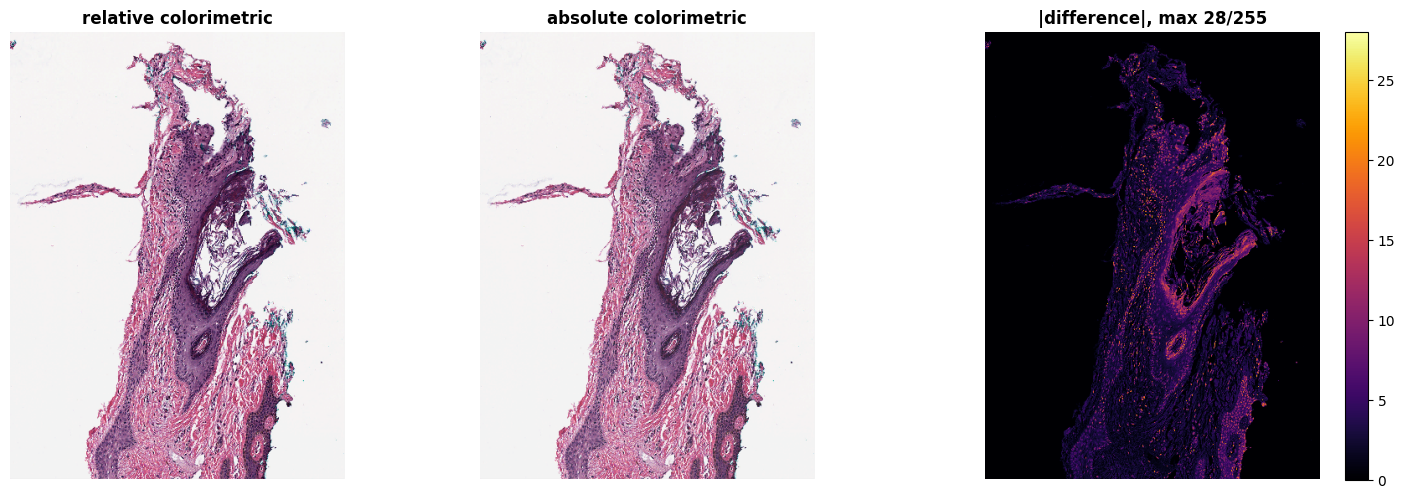

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(images[0]); axes[0].set_title('relative colorimetric', fontweight='bold')
axes[1].imshow(images[3]); axes[1].set_title('absolute colorimetric', fontweight='bold')

difference = np.abs(images[3].astype(float) - images[0].astype(float)).mean(axis=2)
heatmap = axes[2].imshow(difference, cmap='inferno')
axes[2].set_title(f'|difference|, max {difference.max():.0f}/255', fontweight='bold')
fig.colorbar(heatmap, ax=axes[2], fraction=0.046)
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

### Black point compensation

The same LUT profile has a non-zero black point, so turning compensation off is
visible in the shadows: the darkest pixel in the image no longer reaches 0.

In [20]:
rows = []
for enabled in (True, False):
    block = managed(plain, target=slideio.ColorTarget.SRGB,
                    black_point_compensation=enabled,
                    source_profile_override=v4_profile).read_block(size=(400, 0))
    rows.append({'black_point_compensation': enabled,
                 'darkest pixel': int(block.min()),
                 'mean': round(float(block.mean()), 2)})

pd.DataFrame(rows).set_index('black_point_compensation')

,darkest pixel,mean
black_point_compensation,,
True,0,205.55
False,29,206.83


With compensation on, the profile's black maps to 0 and the full output range is
used. With it off, nothing in the image is darker than the profile's own black
point — shadow detail is still there, but it is sitting in a compressed slice of
the range, which matters if a downstream threshold assumes black is 0.

# 5. Slides that carry no profile

This is the common case for pathology, so `ColorManagement` makes you decide
what it means rather than choosing silently.
`missing_profile_policy` takes three values:

| policy | behaviour |
|---|---|
| `ASSUME_SRGB` | treat the pixels as sRGB and convert; result is marked `ASSUMED` (default) |
| `PASS_THROUGH` | do nothing at all; the pixels come through untouched |
| `FAIL` | raise, rather than produce a number that looks measured and is not |

Which one is right depends entirely on what the output is for. A viewer wants
`ASSUME_SRGB`: something has to be shown, and sRGB is the least wrong guess. A
study comparing measurements across sites wants `FAIL`, because a guessed
conversion that silently succeeds is worse than no conversion — it is a
fabricated measurement.

In [21]:
assumed_scene = managed(plain, target=slideio.ColorTarget.LAB,
                        missing_profile_policy=slideio.MissingProfilePolicy.ASSUME_SRGB)
assumed_block = assumed_scene.read_block(size=(200, 0))

print('policy      : ASSUME_SRGB')
print('source      :', assumed_scene.get_color_profile_info().source)
print('output      :', assumed_block.dtype, assumed_block.shape)
print('L range     : '
      f'[{assumed_block[:, :, 0].min():.1f}, {assumed_block[:, :, 0].max():.1f}]')

policy      : ASSUME_SRGB
source      : ColorProfileSource.ASSUMED
output      : float32 (267, 200, 3)
L range     : [0.3, 99.9]


In [22]:
try:
    managed(plain, target=slideio.ColorTarget.LAB,
            missing_profile_policy=slideio.MissingProfilePolicy.FAIL)
except RuntimeError as error:
    print('RuntimeError:', error)

RuntimeError: D:\a\slideio-python\slideio-python\slideio\extern\slideio\src\slideio\transformer\colormanagement.cpp:71:ColorManagement: the scene embeds no ICC profile and the missing profile policy is Fail


Note where that error came from: building the transformation, not reading from
it. The policy is checked when the scene is bound, so a pipeline configured
wrongly fails at setup instead of halfway through a long tile loop.

`PASS_THROUGH` is accepted only with the `SRGB` target, and the refusal is worth
reading — the reason is the data type. Every other target returns float32, so a
pass-through that quietly returned uint8 would mean the dtype of your array
depended on whether the file happened to carry a profile.

In [23]:
passed = managed(plain, target=slideio.ColorTarget.SRGB,
                 missing_profile_policy=slideio.MissingProfilePolicy.PASS_THROUGH)
block = passed.read_block(size=(200, 0))
raw = plain.read_block(size=(200, 0))

print('source                 :', passed.get_color_profile_info().source)
print('output                 :', block.dtype, block.shape)
print('identical to raw read  :', np.array_equal(block, raw))

try:
    managed(plain, target=slideio.ColorTarget.LAB,
            missing_profile_policy=slideio.MissingProfilePolicy.PASS_THROUGH)
except RuntimeError as error:
    print()
    print('RuntimeError:', error)

source                 : ColorProfileSource.NONE
output                 : uint8 (267, 200, 3)
identical to raw read  : True

RuntimeError: D:\a\slideio-python\slideio-python\slideio\extern\slideio\src\slideio\transformer\colormanagement.cpp:76:ColorManagement: PassThrough is only coherent with the sRGB target; with Lab the output data type would depend on whether a file happens to carry a profile


`PASS_THROUGH` is also the one policy that leaves `source` as `NONE`. Nothing was
converted, so nothing is claimed — which is the honest answer, and keeps the
provenance field usable as a filter.

# 6. Supplying a profile yourself

There is no built-in table of fallback profiles per scanner model, and the
omission is deliberate: a table like that would let a pipeline emit colorimetric
numbers derived from a guess about hardware it never measured.

`source_profile_override` is the honest substitute. A lab that has actually
characterised its scanner supplies the profile and owns the claim. Assign raw
ICC bytes — the same form `get_color_profile()` returns — and the conversion
reads from that profile instead of whatever the scene embeds.

Because a real profile is then present, `FAIL` no longer applies: there is
nothing missing.

In [24]:
strict = dict(target=slideio.ColorTarget.LAB,
              missing_profile_policy=slideio.MissingProfilePolicy.FAIL)

try:
    managed(plain, **strict)
except RuntimeError as error:
    print('without an override:', type(error).__name__)
    print(' ', str(error).split(':')[-1].strip())

supplied = managed(plain, source_profile_override=v4_profile, **strict)
supplied_info = supplied.get_color_profile_info()

print()
print('with an override   : converted')
print('  source     :', supplied_info.source)
print('  description:', supplied_info.description)
print('  size       :', supplied_info.size, '== len(profile bytes)',
      supplied_info.size == len(v4_profile))

without an override: RuntimeError
  the scene embeds no ICC profile and the missing profile policy is Fail

with an override   : converted
  source     : ColorProfileSource.SUPPLIED
  description: sRGB_ICC_v4_appearance_beta.icc
  size       : 63928 == len(profile bytes) True


`SUPPLIED`, not `EMBEDDED`. The slide's file still contains no profile, and
reporting one as embedded would misstate where the colorimetry came from — the
exact distinction a provenance field exists to record. The bytes are readable
back off the transformation, and assigning `None` clears the override.

In [25]:
cm = slideio.ColorManagement()
print('override initially :', cm.source_profile_override)

cm.source_profile_override = v4_profile
print('after assignment   :', type(cm.source_profile_override).__name__,
      len(cm.source_profile_override), 'bytes;',
      'round trips exactly:', cm.source_profile_override == v4_profile)

cm.source_profile_override = None
print('after clearing     :', cm.source_profile_override)

try:
    cm.source_profile_override = 'profile.icc'
except TypeError as error:
    print()
    print('TypeError:', error)

override initially : None
after assignment   : bytes 63928 bytes; round trips exactly: True
after clearing     : None

TypeError: source_profile_override expects raw ICC profile bytes or None


A path is rejected rather than loaded, so reading the file is yours to do —
`open(path, 'rb').read()` is the whole of it. That keeps the property that these
bytes came from somewhere you chose.

# 7. Composing with other transformations

`ColorManagement` is an ordinary transformation, so it composes: pass a list and
each one is applied in turn, lazily. This is the usual shape of a real
pipeline — interpret the colour first, *then* do the naive arithmetic, so that
the arithmetic operates on values that mean something.

chained result: uint8 (535, 400)


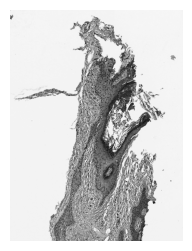

In [26]:
colour = slideio.ColorManagement()
colour.target = slideio.ColorTarget.SRGB

to_gray = slideio.ColorTransformation()
to_gray.color_space = slideio.ColorSpace.GRAY

chained = plain.apply_transformation([colour, to_gray])
gray = chained.read_block(size=(400, 0))

print('chained result:', gray.dtype, gray.shape)
show_image(gray, 300)

Order matters, and not only for the result. `ColorManagement` requires three
channels — an ICC conversion of channels that are not a colorimetric triple is
not a meaningful operation, so it refuses rather than producing numbers. Putting
the grayscale step first therefore fails outright.

In [27]:
try:
    plain.apply_transformation([to_gray, colour])
except RuntimeError as error:
    print('RuntimeError:', error)

RuntimeError: D:\a\slideio-python\slideio-python\slideio\extern\slideio\src\slideio\transformer\colormanagement.cpp:36:ColorManagement: expected a 3 channel RGB image, received 1 channels. ICC conversion of non-colorimetric channels is not meaningful.


The same refusal applies to a fluorescence scene, where the channels are
separate stains rather than red, green and blue. Colour management is for
brightfield RGB; for multi-channel fluorescence there is nothing for an ICC
profile to say.

# Summary

**Reading**

- `scene.get_color_profile()` — raw ICC bytes, or `None`. Any ICC consumer takes them.
- `scene.get_color_profile_info()` — the parsed header: `present`, `source`,
  `description`, `data_space`, `connection_space`, `intent`, `white_point`, `size`.
- `info.source` is the field worth recording: `EMBEDDED` is the scanner's claim,
  `ASSUMED` is a guess, `SUPPLIED` is yours, `NONE` is uninterpreted data.

**Converting**

- `ColorManagement.target` picks the output space. `SRGB` gives uint8;
  `LINEAR_RGB`, `LAB` and `XYZ` give float32.
- `intent` and `black_point_compensation` only change anything for a profile
  with something to say — a matrix/TRC profile makes all four intents identical.
  `RELATIVE_COLORIMETRIC` with compensation on is the default and the right
  default for measurement.
- `missing_profile_policy` decides what an unprofiled slide means:
  `ASSUME_SRGB` to show something, `PASS_THROUGH` to do nothing, `FAIL` to
  refuse to fabricate. The check happens when the transformation is built.
- `source_profile_override` supplies a profile you characterised yourself, and
  marks the result `SUPPLIED`.
- It composes with other transformations, and needs three channels to work on.

Use `ColorTransformation` when you want a different arrangement of the numbers.
Use `ColorManagement` when you need the numbers to mean the same thing on
someone else's scanner.